# Image annotation

In [33]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_evans_blue_final_refined(img_path, scale_px_mm=12.0, bias=12, min_area=300):
    img = cv2.imread(img_path)
    if img is None: return None, None, None

    # 1. Color Isolation
    b, g, r = cv2.split(img)
    diff = cv2.subtract(b, r)

    # 2. Stronger Denoising for "Clean" Edges
    # Gaussian + Median filter removes the small "grainy" artifacts
    blur = cv2.GaussianBlur(diff, (5, 5), 0)
    denoised = cv2.medianBlur(blur, 5)
    
    otsu_thresh, _ = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, mask = cv2.threshold(denoised, otsu_thresh + bias, 255, cv2.THRESH_BINARY)

    # 3. Morphological "Smoothing"
    # Using an ELLIPSE kernel creates more natural, rounded edges
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # 4. Final Contour Selection
    final_cnts = []
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for c in contours:
        area = cv2.contourArea(c)
        if area < min_area: continue
            
        # Use Convex Hull for the VISUAL boundary to keep it clean and artifact-free
        hull = cv2.convexHull(c)
        
        # Geometry check: Filter out very thin artifacts (like hairs or scratches)
        # by checking the ratio of area to bounding box
        x, y, w, h = cv2.boundingRect(hull)
        aspect_ratio = float(w)/h
        if 0.2 < aspect_ratio < 5.0: # Rejects long thin lines
            final_cnts.append(hull)

    # 5. Extraction
    results = []
    vis_img = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    for i, cnt in enumerate(final_cnts):
        area_px = cv2.contourArea(cnt)
        M = cv2.moments(cnt)
        if M['m00'] == 0: continue
        cx, cy = int(M['m10']/M['m00']), int(M['m01']/M['m00'])

        m_mask = np.zeros_like(gray)
        cv2.drawContours(m_mask, [cnt], -1, 255, -1)
        mean_val = cv2.mean(gray, mask=m_mask)[0]

        results.append({
            'ID': i + 1,
            'Area_mm2': round(area_px / (scale_px_mm**2), 2),
            'Intensity': round(mean_val, 2)
        })

        # Draw with thicker, smoother lines
        cv2.drawContours(vis_img, [cnt], -1, (0, 255, 0), 2)
        cv2.putText(vis_img, str(i+1), (cx-10, cy+10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    return pd.DataFrame(results), mask, vis_img

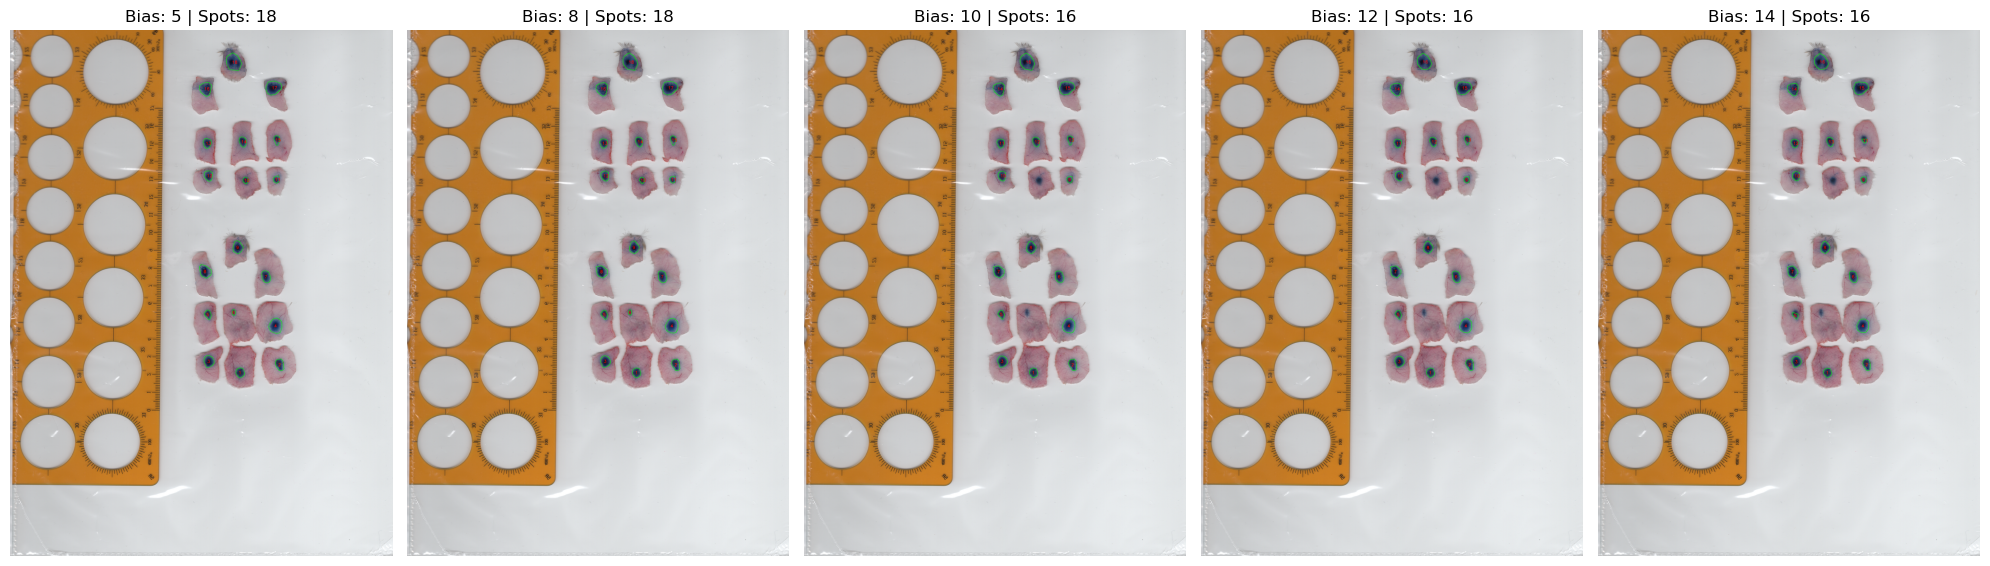

In [37]:
# --- RUN LOOP ---
img_file = 'Image A.tif'
# Try a tighter range. 12 is usually the "sweet spot" for Evans Blue tissue.
BIAS_TESTS = [5, 8, 10, 12, 14] 

fig, axes = plt.subplots(1, len(BIAS_TESTS), figsize=(20, 10))

for i, b in enumerate(BIAS_TESTS):
    df, mask, vis = analyze_evans_blue_final_refined(img_file, bias=b, min_area=400)
    
    axes[i].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Bias: {b} | Spots: {len(df)}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

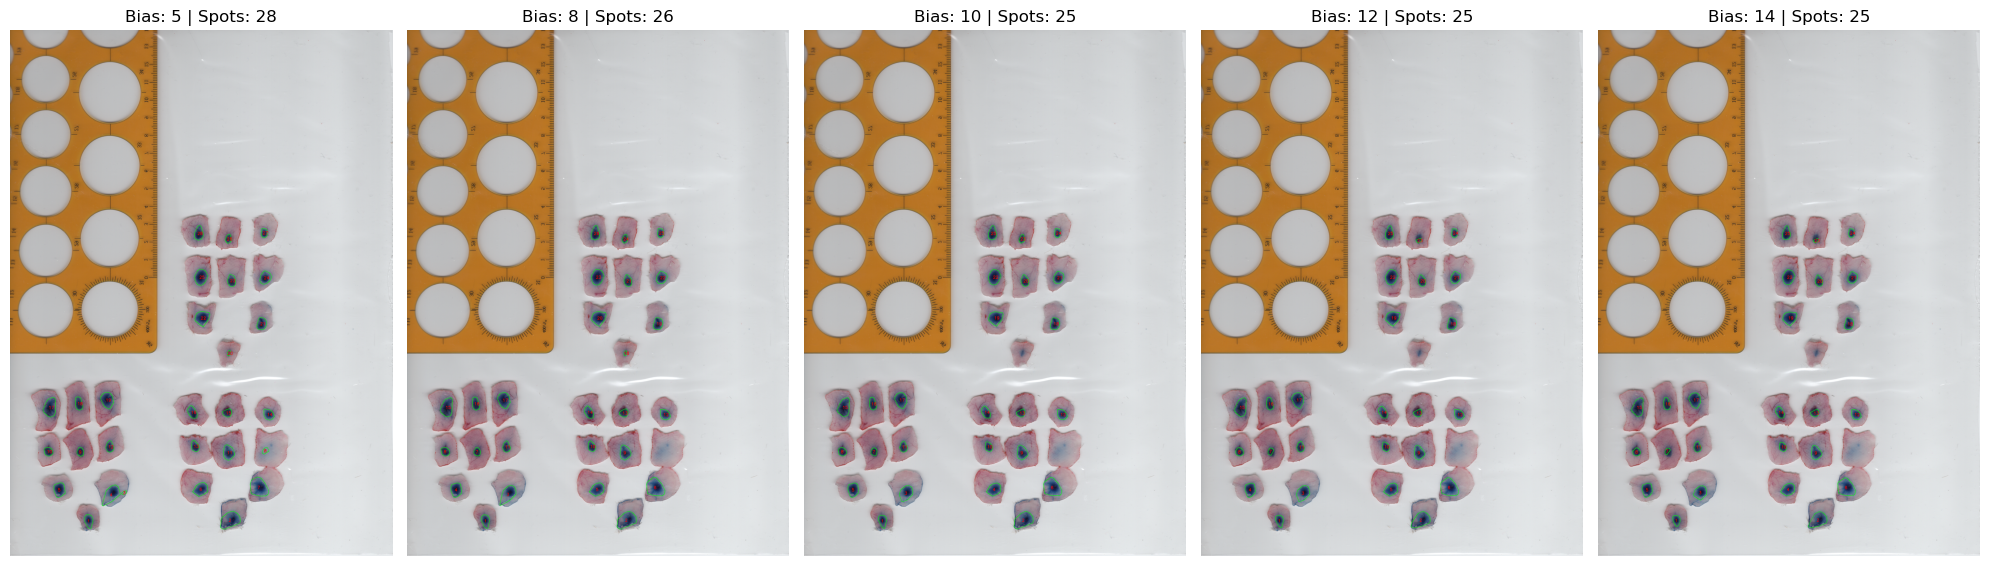

In [36]:
# --- RUN LOOP ---
img_file = 'Image B.tif'
# Try a tighter range. 12 is usually the "sweet spot" for Evans Blue tissue.
BIAS_TESTS = [5, 8, 10, 12, 14] 

fig, axes = plt.subplots(1, len(BIAS_TESTS), figsize=(20, 10))

for i, b in enumerate(BIAS_TESTS):
    df, mask, vis = analyze_evans_blue_final_refined(img_file, bias=b, min_area=400)
    
    axes[i].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Bias: {b} | Spots: {len(df)}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [39]:
# --- RUN LOOP ---
img_file = ['Image A.tif', 'Image B.tif']

for img in img_file:
    name = os.path.splitext(os.path.basename(img))[0]
    df, mask, vis = analyze_evans_blue_final_refined(img, bias=8, min_area=400)
    df.to_csv(f"Analyzed_{name}.csv", index=False)
    cv2.imwrite(f"Mask_{name}.png", mask)
    cv2.imwrite(f"Vis_{name}.png", vis)